<a href="https://colab.research.google.com/github/kcymae/Computational-TCell-Epitope-Analysis/blob/main/2_Exploratory_Data_Analysis_(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Install Dependencies & Load Data**

In [1]:
! pip install pandas numpy matplotlib seaborn scikit-learn matplotlib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("=" * 80)
print("PHASE II: NUMERICAL FEATURES GENERATION & EXPLORATORY DATA ANALYSIS")
print("=" * 80)
print("\n✅ Dependencies loaded successfully!")

PHASE II: NUMERICAL FEATURES GENERATION & EXPLORATORY DATA ANALYSIS

✅ Dependencies loaded successfully!


In [2]:
# Option A: Load from local file (if already downloaded)
try:
    df_phase1 = pd.read_csv("epitope_data_collection_phase1.csv")
    print("✅ Loaded from local file: epitope_data_collection_phase1.csv")
except FileNotFoundError:
    # Option B: Load from GitHub (raw CSV)
    url = "https://raw.githubusercontent.com/kcymae/Computational-TCell-Epitope-Analysis/main/epitope_data_collection_phase1.csv"
    df_phase1 = pd.read_csv(url)
    print("✅ Loaded from GitHub repository")

print(f"\n📊 Dataset Overview:")
print(f"   Rows: {len(df_phase1)}")
print(f"   Columns: {len(df_phase1.columns)}")
print(f"\n🔍 First few rows:")
print(df_phase1.head())

print(f"\n📋 Column names:")
for col in df_phase1.columns:
    print(f"   • {col}")

HTTPError: HTTP Error 404: Not Found

Alternative: Load directly from Github

In [ ]:
import pandas as pd

# Load directly from your GitHub repo (no manual upload needed!)
url = "https://raw.githubusercontent.com/kcymae/Project-/main/epitope_prediction_combined.csv"
combined_df = pd.read_csv(url)
print(combined_df.head())

     peptide       allele    score  percentile_rank
0  MFVFLVLLP  HLA-A*02:01  0.00013             31.0
1  FVFLVLLPL  HLA-A*02:01  0.04690              2.2
2  VFLVLLPLV  HLA-A*02:01  0.00903              5.2
3  FLVLLPLVS  HLA-A*02:01  0.01370              4.3
4  LVLLPLVSS  HLA-A*02:01  0.00392              7.7


**T-Cell Epitope Predictions**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

**I. Load and Inspect Data**

In [ ]:
combined_df = pd.read_csv("epitope_prediction_combined.csv")

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"\n📊 Total epitope predictions: {len(combined_df)}")
print(f"📋 Total columns: {len(combined_df.columns)}")
print(f"\n🔍 Column names:")
print(combined_df.columns.tolist())
print(f"\n📈 Dataset shape: {combined_df.shape}")
print(f"\n🔎 First 10 rows:")
print(combined_df.head(10))

# Check for missing values
print(f"\n⚠️ Missing values:")
print(combined_df.isnull().sum())

DATASET OVERVIEW

📊 Total epitope predictions: 50
📋 Total columns: 4

🔍 Column names:
['peptide', 'allele', 'score', 'percentile_rank']

📈 Dataset shape: (50, 4)

🔎 First 10 rows:
     peptide       allele     score  percentile_rank
0  MFVFLVLLP  HLA-A*02:01  0.000130             31.0
1  FVFLVLLPL  HLA-A*02:01  0.046900              2.2
2  VFLVLLPLV  HLA-A*02:01  0.009030              5.2
3  FLVLLPLVS  HLA-A*02:01  0.013700              4.3
4  LVLLPLVSS  HLA-A*02:01  0.003920              7.7
5  VLLPLVSSQ  HLA-A*02:01  0.009190              5.2
6  LLPLVSSQC  HLA-A*02:01  0.022100              3.4
7  LPLVSSQCV  HLA-A*02:01  0.000288             23.0
8  PLVSSQCVN  HLA-A*02:01  0.000003             82.0
9  LVSSQCVNL  HLA-A*02:01  0.025500              3.1

⚠️ Missing values:
peptide            0
allele             0
score              0
percentile_rank    0
dtype: int64


**II. Statistical Summary**

In [ ]:
print("\n" + "=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

print(f"\n📊 Basic Statistics for Key Columns:")
print(combined_df[['score', 'percentile_rank']].describe())

# Key metrics
print(f"\n🏆 KEY FINDINGS:")
print(f"  • Best score (lowest): {combined_df['score'].min():.6f} nM")
print(f"  • Worst score (highest): {combined_df['score'].max():.6f} nM")
print(f"  • Average score: {combined_df['score'].mean():.6f} nM")
print(f"  • Median Percentile Rank: {combined_df['percentile_rank'].median():.2f}%")
print(f"  • Standard Deviation (score): {combined_df['score'].std():.6f}")


STATISTICAL SUMMARY

📊 Basic Statistics for Key Columns:
           score  percentile_rank
count  50.000000         50.00000
mean    0.006501         26.97800
std     0.018888         23.65114
min     0.000002          1.20000
25%     0.000073          8.82500
50%     0.000441         20.00000
75%     0.002860         37.75000
max     0.122000         87.00000

🏆 KEY FINDINGS:
  • Best score (lowest): 0.000002 nM
  • Worst score (highest): 0.122000 nM
  • Average score: 0.006501 nM
  • Median Percentile Rank: 20.00%
  • Standard Deviation (score): 0.018888


**III. Categorize Binders by Strength**

In [ ]:
print("\n" + "=" * 70)
print("BINDER CLASSIFICATION")
print("=" * 70)

# Create categories based on score values (lower is better)
def categorize_binder(score):
    if score < 0.5:
        return "Very Strong Binder"
    elif score < 5:
        return "Strong Binder"
    elif score < 500:
        return "Moderate Binder"
    else:
        return "Weak Binder"

combined_df['Binder_Category'] = combined_df['score'].apply(categorize_binder)

print(f"\n📊 Binder Strength Distribution:")
binder_counts = combined_df['Binder_Category'].value_counts()
for category, count in binder_counts.items():
    percentage = (count / len(combined_df)) * 100
    print(f"  • {category}: {count} ({percentage:.1f}%)")



BINDER CLASSIFICATION

📊 Binder Strength Distribution:
  • Very Strong Binder: 50 (100.0%)


**IV. Identify Top Epitope Candidates**

In [ ]:
print("\n" + "=" * 70)
print("TOP 15 HIGH-AFFINITY EPITOPE CANDIDATES")
print("=" * 70)

top_15_epitopes = combined_df.nsmallest(15, 'score')[['peptide', 'allele', 'score', 'percentile_rank', 'Binder_Category']]
print("\n")
print(top_15_epitopes.to_string(index=False))

# Save top candidates
top_15_epitopes.to_csv("top_15_epitope_candidates.csv", index=False)
print("\n✅ Top 15 candidates saved to: top_15_epitope_candidates.csv")


TOP 15 HIGH-AFFINITY EPITOPE CANDIDATES


  peptide      allele    score  percentile_rank    Binder_Category
PPAYTNSFT HLA-A*02:01 0.000002             87.0 Very Strong Binder
PLVSSQCVN HLA-A*02:01 0.000003             82.0 Very Strong Binder
AYTNSFTRG HLA-A*02:01 0.000004             78.0 Very Strong Binder
TRGVYYPDK HLA-A*02:01 0.000006             73.0 Very Strong Binder
PDKVFRSSV HLA-A*02:01 0.000008             69.0 Very Strong Binder
SSVLHSTQD HLA-A*02:01 0.000010             66.0 Very Strong Binder
FTRGVYYPD HLA-A*02:01 0.000012             63.0 Very Strong Binder
TNSFTRGVY HLA-A*02:01 0.000013             62.0 Very Strong Binder
DKVFRSSVL HLA-A*02:01 0.000024             53.0 Very Strong Binder
RSSVLHSTQ HLA-A*02:01 0.000048             43.0 Very Strong Binder
CVNLTTRTQ HLA-A*02:01 0.000049             43.0 Very Strong Binder
QCVNLTTRT HLA-A*02:01 0.000060             40.0 Very Strong Binder
LTTRTQLPP HLA-A*02:01 0.000064             39.0 Very Strong Binder
VFRSSVLHS HLA-A*02:

**V. Correlation Analysis**


CORRELATION ANALYSIS

📊 Correlation Matrix:
                   score  percentile_rank
score            1.00000         -0.35084
percentile_rank -0.35084          1.00000


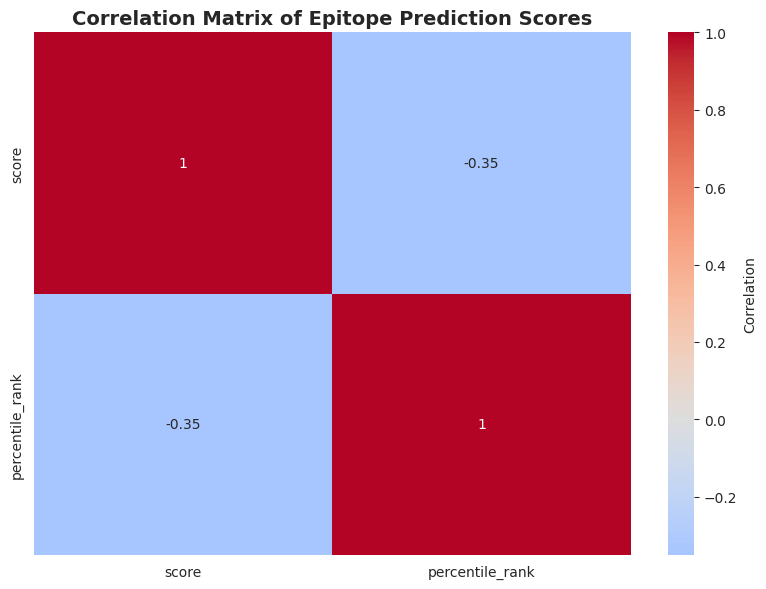

In [ ]:
print("\n" + "=" * 70)
print("CORRELATION ANALYSIS")
print("=" * 70)

# Select numeric columns for correlation
numeric_cols = ['score', 'percentile_rank']
correlation_matrix = combined_df[numeric_cols].corr()

print("\n📊 Correlation Matrix:")
print(correlation_matrix)

# Visualize correlation
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of Epitope Prediction Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**VI. Distribution Visualization**


GENERATING DISTRIBUTION PLOTS


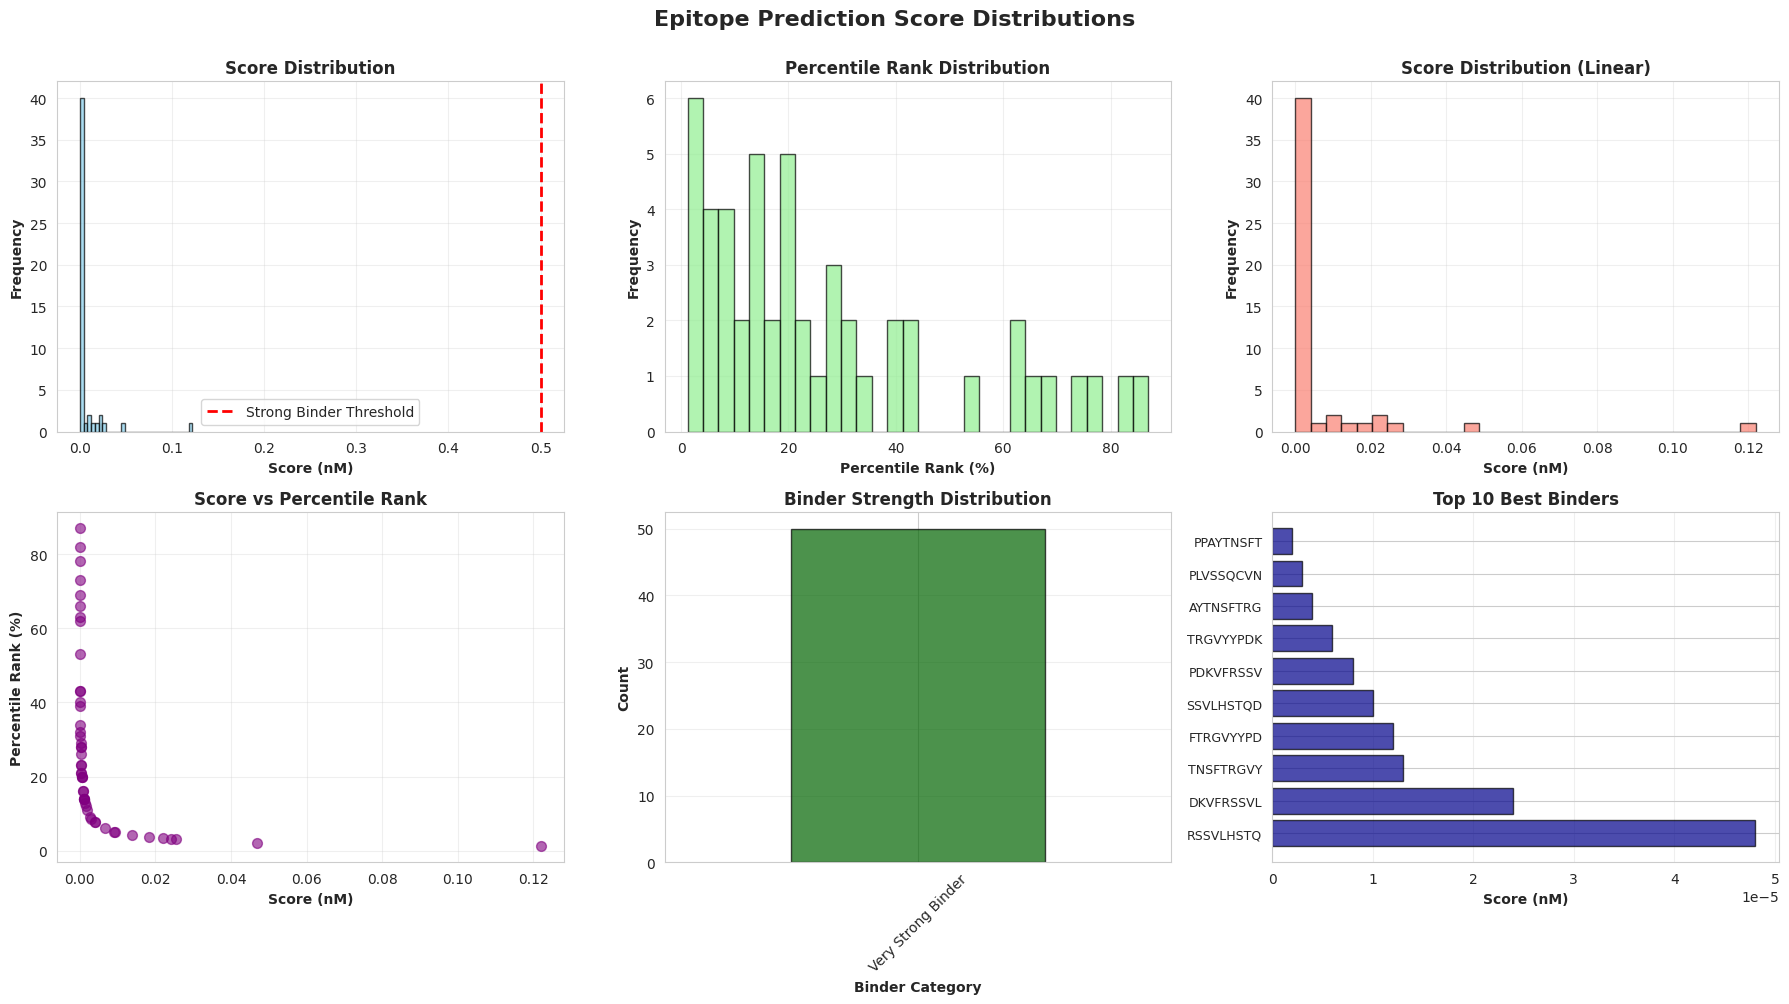

✅ Distribution plots saved to: epitope_eda_distributions.png


In [ ]:
print("\n" + "=" * 70)
print("GENERATING DISTRIBUTION PLOTS")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Epitope Prediction Score Distributions', fontsize=16, fontweight='bold', y=1.00)

# 1. Score Distribution
axes[0, 0].hist(combined_df['score'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Strong Binder Threshold')
axes[0, 0].set_xlabel('Score (nM)', fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontweight='bold')
axes[0, 0].set_title('Score Distribution', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Percentile Rank Distribution
axes[0, 1].hist(combined_df['percentile_rank'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Percentile Rank (%)', fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontweight='bold')
axes[0, 1].set_title('Percentile Rank Distribution', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# 3. Score Distribution (Log Scale)
axes[0, 2].hist(combined_df['score'], bins=30, color='salmon', edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Score (nM)', fontweight='bold')
axes[0, 2].set_ylabel('Frequency', fontweight='bold')
axes[0, 2].set_title('Score Distribution (Linear)', fontweight='bold')
axes[0, 2].grid(alpha=0.3)

# 4. Score vs Percentile Rank (Scatter)
axes[1, 0].scatter(combined_df['score'], combined_df['percentile_rank'], alpha=0.6, s=50, color='purple')
axes[1, 0].set_xlabel('Score (nM)', fontweight='bold')
axes[1, 0].set_ylabel('Percentile Rank (%)', fontweight='bold')
axes[1, 0].set_title('Score vs Percentile Rank', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 5. Binder Category Distribution (Bar Chart)
binder_counts.plot(kind='bar', ax=axes[1, 1], color=['darkgreen', 'green', 'orange', 'red'], alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Binder Category', fontweight='bold')
axes[1, 1].set_ylabel('Count', fontweight='bold')
axes[1, 1].set_title('Binder Strength Distribution', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(alpha=0.3, axis='y')

# 6. Top 10 Epitopes Bar Chart
top_10 = combined_df.nsmallest(10, 'score')
axes[1, 2].barh(range(len(top_10)), top_10['score'], color='darkblue', alpha=0.7, edgecolor='black')
axes[1, 2].set_yticks(range(len(top_10)))
axes[1, 2].set_yticklabels(top_10['peptide'], fontsize=9)
axes[1, 2].set_xlabel('Score (nM)', fontweight='bold')
axes[1, 2].set_title('Top 10 Best Binders', fontweight='bold')
axes[1, 2].invert_yaxis()
axes[1, 2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('epitope_eda_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Distribution plots saved to: epitope_eda_distributions.png")


**VII. Box Plot by Category**


GENERATING CATEGORY COMPARISON PLOTS


/tmp/ipykernel_8339/1576698035.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='Binder_Category', y='score', ax=axes[0], palette='Set2')
/tmp/ipykernel_8339/1576698035.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='Binder_Category', y='percentile_rank', ax=axes[1], palette='Set2')


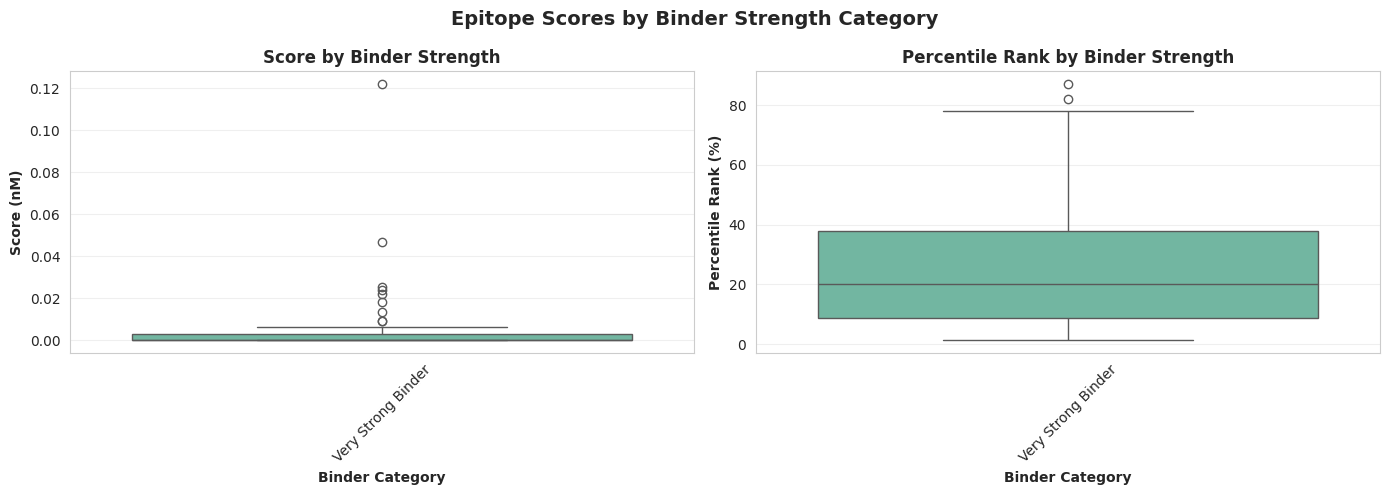

✅ Box plots saved to: epitope_eda_boxplots.png


In [ ]:
print("\n" + "=" * 70)
print("GENERATING CATEGORY COMPARISON PLOTS")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Epitope Scores by Binder Strength Category', fontsize=14, fontweight='bold')

# Box plot 1: Score by Category
sns.boxplot(data=combined_df, x='Binder_Category', y='score', ax=axes[0], palette='Set2')
axes[0].set_xlabel('Binder Category', fontweight='bold')
axes[0].set_ylabel('Score (nM)', fontweight='bold')
axes[0].set_title('Score by Binder Strength', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3, axis='y')

# Box plot 2: Percentile Rank by Category
sns.boxplot(data=combined_df, x='Binder_Category', y='percentile_rank', ax=axes[1], palette='Set2')
axes[1].set_xlabel('Binder Category', fontweight='bold')
axes[1].set_ylabel('Percentile Rank (%)', fontweight='bold')
axes[1].set_title('Percentile Rank by Binder Strength', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('epitope_eda_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Box plots saved to: epitope_eda_boxplots.png")


**SUMMARY AND RECOMMENDATIONS**

In [ ]:
print("\n" + "=" * 70)
print("SUMMARY & RECOMMENDATIONS FOR MOLECULAR DOCKING")
print("=" * 70)

strong_binders = combined_df[combined_df['score'] < 0.5]

print(f"\n🎯 RECOMMENDED EPITOPES FOR MOLECULAR DOCKING:")
print(f"   • Total strong binders (score < 0.5): {len(strong_binders)}")
print(f"\n   Top 5 candidates to dock:")
for idx, (i, row) in enumerate(strong_binders.nsmallest(5, 'score').iterrows(), 1):
    print(f"   {idx}. {row['peptide']} (Score: {row['score']:.6f} nM, Rank: {row['percentile_rank']:.2f}%)")

# Save strong binders for docking
strong_binders.to_csv("strong_binders_for_molecular_docking.csv", index=False)
print(f"\n✅ Strong binders saved to: strong_binders_for_molecular_docking.csv")

print("\n" + "=" * 70)
print("EDA COMPLETE! 🎉")
print("=" * 70)
print("\nNext Steps:")
print("  1. Review the top epitope candidates above")
print("  2. Use 'strong_binders_for_molecular_docking.csv' for docking")
print("  3. Proceed to Molecular Docking Analysis (Part 3)")
print("=" * 70)


SUMMARY & RECOMMENDATIONS FOR MOLECULAR DOCKING

🎯 RECOMMENDED EPITOPES FOR MOLECULAR DOCKING:
   • Total strong binders (score < 0.5): 50

   Top 5 candidates to dock:
   1. PPAYTNSFT (Score: 0.000002 nM, Rank: 87.00%)
   2. PLVSSQCVN (Score: 0.000003 nM, Rank: 82.00%)
   3. AYTNSFTRG (Score: 0.000004 nM, Rank: 78.00%)
   4. TRGVYYPDK (Score: 0.000006 nM, Rank: 73.00%)
   5. PDKVFRSSV (Score: 0.000008 nM, Rank: 69.00%)

✅ Strong binders saved to: strong_binders_for_molecular_docking.csv

EDA COMPLETE! 🎉

Next Steps:
  1. Review the top epitope candidates above
  2. Use 'strong_binders_for_molecular_docking.csv' for docking
  3. Proceed to Molecular Docking Analysis (Part 3)
